<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/ReduccionDimensionalidad_SESION_29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reducción de la Dimensionalidad

Ejercicios prácticos sobre reducciòn de la dimensionalidad. Primero definimos algunas bibliotecas

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_breast_cancer, load_diabetes
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, RFECV, SelectFromModel
from sklearn.metrics import accuracy_score, f1_score
rng = np.random.RandomState(42)


## Wrapper

In [2]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

model = LogisticRegression(max_iter=2000)
rfe = RFE(estimator=model, n_features_to_select=10)
rfe.fit(X_scaled, y)

print("Características seleccionadas:", np.where(rfe.support_)[0])
print("Ranking:", rfe.ranking_)


Características seleccionadas: [ 7 10 13 15 20 21 22 23 26 27]
Ranking: [ 7  9 10  3 18  5  8  1 20 15  1 17  4  1 13  1 19 16 12 11  1  1  1  1
  2 21  1  1  6 14]


RFECV – Selección óptima con validación cruzada

Número óptimo de características: 30


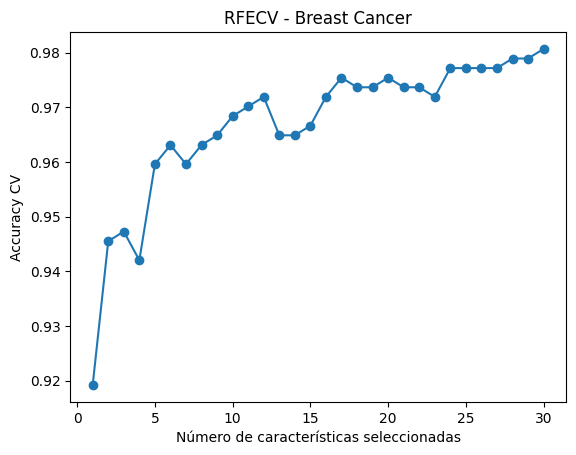

In [3]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5), scoring='accuracy')
rfecv.fit(X_scaled, y)

print("Número óptimo de características:", rfecv.n_features_)
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o')
plt.xlabel("Número de características seleccionadas")
plt.ylabel("Accuracy CV")
plt.title("RFECV - Breast Cancer")
plt.show()

Sequential Feature Selector (SFS)

In [4]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.svm import SVC

svc = SVC(kernel='linear')
sfs = SequentialFeatureSelector(
    estimator=svc,
    n_features_to_select=8,
    direction='forward',  # o 'backward'
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
sfs.fit(X_scaled, y)

print("Índices seleccionados:", np.where(sfs.get_support())[0])


Índices seleccionados: [ 5  9 14 21 23 24 26 28]


Variance Threshold – elimina columnas sin variación

In [5]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np

X = np.array([[0, 2, 0, 3],
              [0, 1, 4, 3],
              [0, 1, 1, 3]])
sel = VarianceThreshold(threshold=0.0)  # elimina las columnas con varianza = 0
X_sel = sel.fit_transform(X)
print("Forma original:", X.shape, "→ tras filtrado:", X_sel.shape)


Forma original: (3, 4) → tras filtrado: (3, 2)


ANOVA F-test (f_classif)

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

X, y = load_wine(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X_scaled, y)
print("Índices seleccionados:", selector.get_support(indices=True))


Índices seleccionados: [ 0  6  9 11 12]


Chi-cuadrado (para datos categóricos o no negativos)

In [7]:
from sklearn.feature_selection import chi2
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
selector = SelectKBest(chi2, k=10)
X_new = selector.fit_transform(X, y)
print("Características seleccionadas:", selector.get_support(indices=True))


Características seleccionadas: [20 21 26 30 33 34 42 43 54 62]


Información mutua (no lineal)

In [8]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X) # Recalculate X_scaled for the current X (load_digits)
mi = mutual_info_classif(X_scaled, y)
pd.DataFrame({"Feature": range(X.shape[1]), "Score": mi}).sort_values("Score", ascending=False)

,Feature,Score
34,34,0.437562
26,26,0.435672
21,21,0.430722
33,33,0.426040
42,42,0.409751
...,...,...
16,16,0.000000
47,47,0.000000
39,39,0.000000
32,32,0.000000


SelectPercentile

In [9]:
from sklearn.feature_selection import SelectPercentile, f_classif

sel = SelectPercentile(score_func=f_classif, percentile=30)
X_new = sel.fit_transform(X_scaled, y)
print("Porcentaje retenido:", sel.percentile, "%")


Porcentaje retenido: 30 %


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 0 32 39] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [10]:
!pip -q install umap-learn

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
import umap


Embedded

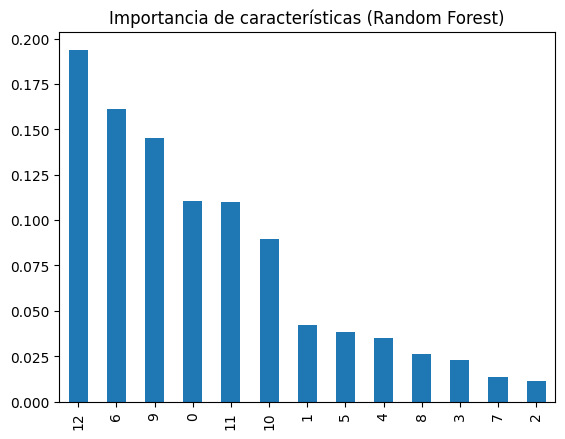

In [11]:
X, y = load_wine(return_X_y=True)
scaler = StandardScaler()
Xz = scaler.fit_transform(X)
rf = RandomForestClassifier(random_state=0).fit(Xz, y)
importances = pd.Series(rf.feature_importances_)
importances.sort_values(ascending=False).plot.bar()
plt.title("Importancia de características (Random Forest)")
plt.show()


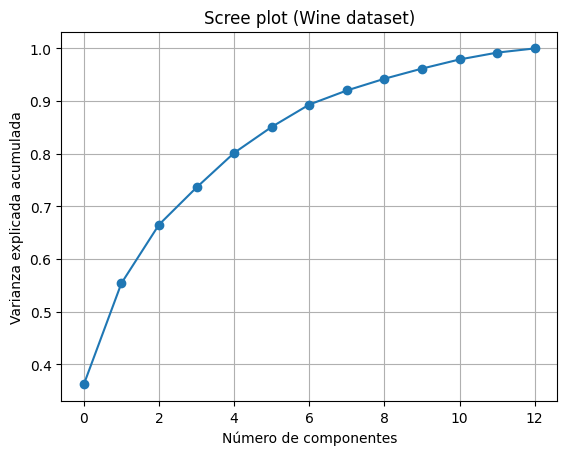

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import numpy as np

X, y = load_wine(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA().fit(X_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Scree plot (Wine dataset)')
plt.grid(True)
plt.show()


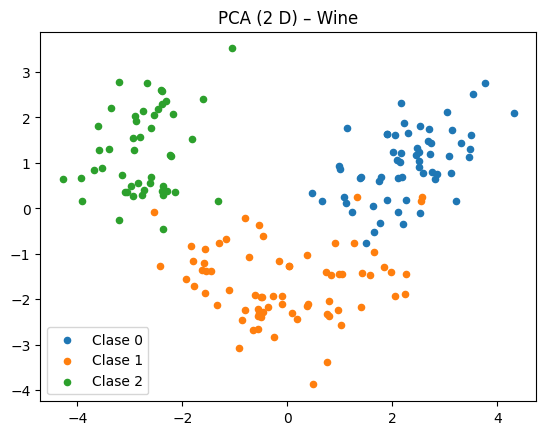

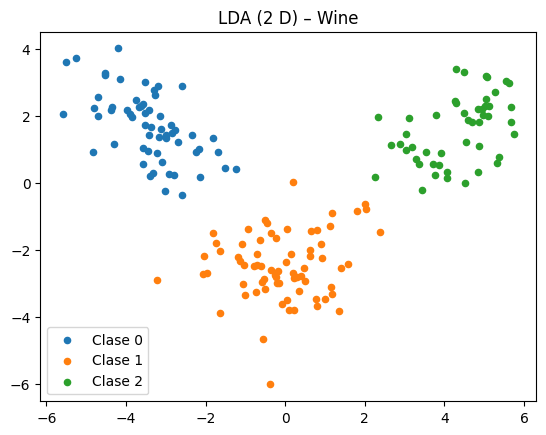

In [13]:
pca = PCA(n_components=2).fit(Xz)
X_pca = pca.transform(Xz)

plt.figure()
for c in np.unique(y):
    plt.scatter(X_pca[y==c,0], X_pca[y==c,1], label=f'Clase {c}', s=20)
plt.legend(); plt.title('PCA (2 D) – Wine'); plt.show()

lda = LDA(n_components=2).fit(Xz, y)
X_lda = lda.transform(Xz)
plt.figure()
for c in np.unique(y):
    plt.scatter(X_lda[y==c,0], X_lda[y==c,1], label=f'Clase {c}', s=20)
plt.legend(); plt.title('LDA (2 D) – Wine'); plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


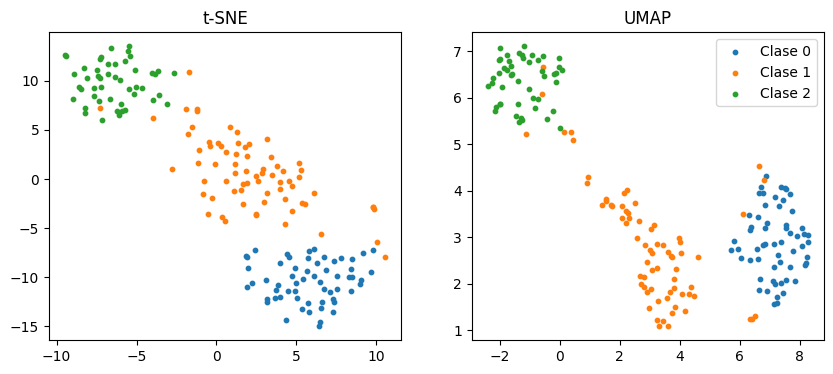

In [14]:
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(Xz)
X_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(Xz)

fig, ax = plt.subplots(1,2,figsize=(10,4))
for c in np.unique(y):
    ax[0].scatter(X_tsne[y==c,0], X_tsne[y==c,1], s=10, label=f'Clase {c}')
    ax[1].scatter(X_umap[y==c,0], X_umap[y==c,1], s=10, label=f'Clase {c}')
ax[0].set_title('t-SNE'); ax[1].set_title('UMAP')
plt.legend(); plt.show()
